In [1]:
import os
import sys
import shutil
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import yaml
from chroma import structure, plotting, convert
from OpenMiChroM.CndbTools import cndbTools as ctools
from matplotlib.lines import Line2D
import seaborn as sns
import hicstraw
import pandas
from chroma import energy
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

plt.style.use("chroma.tex")

# initial tests

In [2]:
color_palette = yaml.safe_load(open("../color-palette.yaml", "r"))

In [3]:
title = {
    "complete": r"$\in~$lamina",
    "nucleolus": r"$\notin~$lamina",
}

In [5]:
plt.rcParams["figure.dpi"] = 1000

In [60]:
traj = ctools()
traj.load("/scratch/mm146/Polarization/4_IMR-90_hg38_chr1/6_sampling/complete/1/nucleus_0.cndb")

Cndb file has 10000 frames, with 4980 beads and {b'A1', b'NA', b'A2', b'B2', b'B3', b'B1'} types 

In [61]:
chr_sequence = np.array([x.decode("utf-8") for x in traj.ChromSeq])

In [63]:
idx_B = (chr_sequence == "B1") | (chr_sequence == "B2") | (chr_sequence == "B3")

In [64]:
idx_B

array([ True,  True,  True, ..., False, False, False])

In [65]:
len(chr_sequence), np.sum(idx_B)

(4980, 2442)

In [6]:
np.where(idx_B)[0]

array([   0,    1,    2, ..., 4972, 4973, 4974])

In [7]:
positions = traj.xyz(frames=[0], beadSelection=[x for x in np.where(idx_B)[0]])[0]

In [8]:
positions.shape

(2442, 3)

In [61]:
energy._contact_switch(1.44)

0.8993116921516865

In [112]:
1.78 - 1/3.22 * np.arctanh(2 * 0.9 - 1)

1.4388160594198418

In [49]:
d_c = 1.44
rho_min = 0.2
delta_min = 0.2

In [50]:
distance_matrix = dc.distance_matrix(positions)

Calculating pairwise distance matrix for 2442 samples


In [51]:
rho = dc.local_density(distance_matrix, d_c, normalize=True)

In [52]:
delta,nearest = dc.distance_to_larger_density(distance_matrix, rho, normalize=True)

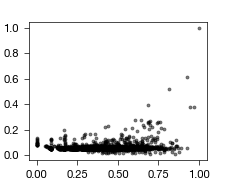

In [53]:
fig, ax = plt.subplots(figsize=(2.3, 1.8))

ax.scatter(rho, delta, s=5, c="k", alpha=0.5)

In [62]:
# Find the cluster centers
centers = dc.cluster_centers(rho, delta, rho_min=0.5, delta_min=0.2)

# Assign cluster ID's to all datapoints
ids = dc.assign_cluster_id(rho, nearest, centers)

# Identify the data that belongs with the cluster cores
core = dc.cluster_cores(distance_matrix, d_c, rho, ids)

In [63]:
(core == True).sum()

271

/tmp/ipykernel_2328023/2613653113.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(cluster_ids), 1))


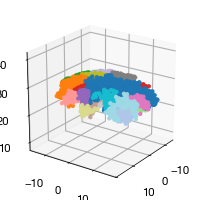

In [64]:
%matplotlib widget

xyz = positions[:, :3]
unassigned = ids < 0
cluster_ids = np.unique(ids[~unassigned])
cmap = plt.cm.get_cmap("tab20", max(len(cluster_ids), 1))

fig = plt.figure(figsize=(2, 2))
ax = fig.add_subplot(111, projection="3d")

for i, cid in enumerate(cluster_ids):
    mask = ids == cid
    ax.scatter(
        xyz[mask, 0],
        xyz[mask, 1],
        xyz[mask, 2],
        s=10,
        color=cmap(i),
        alpha=0.95,
        linewidths=0,
    )

# Overlay only truly unassigned points in black.
# If the clustering method assigns every point, this layer will be empty.
ax.scatter(
    xyz[unassigned, 0],
    xyz[unassigned, 1],
    xyz[unassigned, 2],
    c="black",
    s=10,
    alpha=0.9,
    linewidths=0,
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

mins = xyz.min(axis=0)
maxs = xyz.max(axis=0)
center = 0.5 * (mins + maxs)
radius = 0.5 * np.max(maxs - mins)
ax.set_xlim(center[0] - radius, center[0] + radius)
ax.set_ylim(center[1] - radius, center[1] + radius)
ax.set_zlim(center[2] - radius, center[2] + radius)
ax.set_box_aspect((1, 1, 1))

ax.view_init(elev=22, azim=35)
plt.tight_layout()
plt.show()


In [65]:
counts = np.bincount(ids[ids >= 0])
largest_cluster_size = counts.max()
largest_cluster_id = counts.argmax()

largest_cluster_size, largest_cluster_id

(326, 1)

In [66]:
mask = ids == largest_cluster_id
points_in_largest_cluster = positions[mask]

In [67]:
# Minimum distance between any two different clusters.
# This ignores unassigned points (ids < 0).
cluster_ids = np.unique(ids[ids >= 0])
min_intercluster_distance = np.inf
closest_cluster_pair = None
closest_point_pair = None

for i, cid_a in enumerate(cluster_ids[:-1]):
    points_a = np.where(ids == cid_a)[0]
    for cid_b in cluster_ids[i + 1:]:
        points_b = np.where(ids == cid_b)[0]
        block = distance_matrix[np.ix_(points_a, points_b)]
        local_min_ix = np.unravel_index(np.argmin(block), block.shape)
        local_min = block[local_min_ix]
        if local_min < min_intercluster_distance:
            min_intercluster_distance = local_min
            closest_cluster_pair = (cid_a, cid_b)
            closest_point_pair = (points_a[local_min_ix[0]], points_b[local_min_ix[1]])

min_intercluster_distance, closest_cluster_pair, closest_point_pair


(0.9175408143773814, (3, 5), (1566, 1565))

Found 291 hierarchical clusters at cutoff 1.44
Cluster sizes: {0: 1, 1: 1, 2: 2, 3: 2, 4: 1, 5: 1, 6: 1, 7: 1, 8: 24, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 2, 15: 4, 16: 1, 17: 1, 18: 1, 19: 1, 20: 4, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 2, 33: 1, 34: 1, 35: 1, 36: 1, 37: 1, 38: 2, 39: 1, 40: 1, 41: 4, 42: 1, 43: 1, 44: 1, 45: 2, 46: 1, 47: 2, 48: 3, 49: 1, 50: 2, 51: 1, 52: 1, 53: 1, 54: 6, 55: 1, 56: 1, 57: 3, 58: 2, 59: 2, 60: 1, 61: 1, 62: 1, 63: 2, 64: 2, 65: 3, 66: 2, 67: 1, 68: 1, 69: 2, 70: 1, 71: 1, 72: 1, 73: 1, 74: 5, 75: 3, 76: 2, 77: 2, 78: 2, 79: 5, 80: 7, 81: 3, 82: 3, 83: 3, 84: 5, 85: 3, 86: 2, 87: 2, 88: 2, 89: 4, 90: 2, 91: 2057, 92: 1, 93: 1, 94: 1, 95: 1, 96: 1, 97: 1, 98: 1, 99: 1, 100: 1, 101: 1, 102: 1, 103: 1, 104: 1, 105: 1, 106: 1, 107: 1, 108: 1, 109: 1, 110: 1, 111: 1, 112: 1, 113: 1, 114: 1, 115: 1, 116: 1, 117: 1, 118: 1, 119: 1, 120: 1, 121: 1, 122: 1, 123: 1, 124: 1, 125: 1, 126: 1, 127: 1, 128: 1, 129: 1, 130

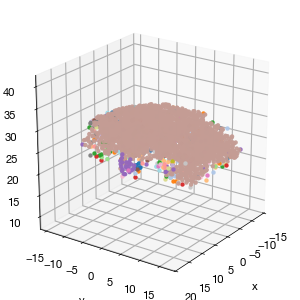

array([ 55, 172,  86, ...,  91, 106,  91], dtype=int32)

In [ ]:

# Hierarchical clustering on Euclidean distances between points.
# We mask out backbone-near pairs so the cutoff does not connect points
# that are adjacent on the polymer chain.
# Single linkage keeps two clusters separate only when the closest
# pair of points between them is farther than 1.44.
xyz = positions[:, :3]
backbone_skip = 2  # ignore first and second neighbors along the chain
D = squareform(pdist(xyz, metric="euclidean"))
big = D.max() + 1.0

for offset in range(1, backbone_skip + 1):
    i = np.arange(len(D) - offset)
    j = i + offset
    D[i, j] = big
    D[j, i] = big

condensed_distances = squareform(D, checks=False)
Z = linkage(condensed_distances, method="single")
hierarchical_ids = fcluster(Z, t=1.44, criterion="distance") - 1

cluster_ids = np.unique(hierarchical_ids)
cluster_sizes = np.array([(hierarchical_ids == cid).sum() for cid in cluster_ids])

print(f"Found {len(cluster_ids)} hierarchical clusters at cutoff 1.44")
print("Cluster sizes:", dict(zip(cluster_ids, cluster_sizes)))

fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot(111, projection="3d")
cmap = plt.colormaps["tab20"]

for i, cid in enumerate(cluster_ids):
    mask = hierarchical_ids == cid
    ax.scatter(
        xyz[mask, 0],
        xyz[mask, 1],
        xyz[mask, 2],
        s=10,
        color=cmap(i % cmap.N),
        alpha=0.95,
        linewidths=0,
    )

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

mins = xyz.min(axis=0)
maxs = xyz.max(axis=0)
center = 0.5 * (mins + maxs)
radius = 0.5 * np.max(maxs - mins)
ax.set_xlim(center[0] - radius, center[0] + radius)
ax.set_ylim(center[1] - radius, center[1] + radius)
ax.set_zlim(center[2] - radius, center[2] + radius)
ax.set_box_aspect((1, 1, 1))

ax.view_init(elev=22, azim=35)
plt.tight_layout()
plt.show()

hierarchical_ids


In [70]:
fmax = []

positions = traj.xyz(frames=range(0,10_000,10), beadSelection=[x for x in np.where(idx_B)[0]])

In [71]:
for frame in range(positions.shape[0]):
    xyz = positions[frame, :, :3]
    D = squareform(pdist(xyz, metric="euclidean"))
    big = D.max() + 1.0

    for offset in range(1, backbone_skip + 1):
        i = np.arange(len(D) - offset)
        j = i + offset
        D[i, j] = big
        D[j, i] = big

    condensed_distances = squareform(D, checks=False)
    Z = linkage(condensed_distances, method="single")
    hierarchical_ids = fcluster(Z, t=1.44, criterion="distance") - 1

    cluster_ids = np.unique(hierarchical_ids)
    cluster_sizes = np.array([(hierarchical_ids == cid).sum() for cid in cluster_ids])

    fmax.append(cluster_sizes.max()/positions.shape[1])

In [72]:
traj = ctools()
traj.load("/scratch/mm146/Polarization/4_IMR-90_hg38_chr1/6_sampling/nucleolus/1/nucleus_0.cndb")

Cndb file has 10000 frames, with 4980 beads and {b'A2', b'NA', b'B2', b'A1', b'B3', b'B1'} types 

In [73]:
fmax_no_lam = []

positions = traj.xyz(frames=range(0,10_000,10), beadSelection=[x for x in np.where(idx_B)[0]])

for frame in range(positions.shape[0]):
    xyz = positions[frame, :, :3]
    D = squareform(pdist(xyz, metric="euclidean"))
    big = D.max() + 1.0

    for offset in range(1, backbone_skip + 1):
        i = np.arange(len(D) - offset)
        j = i + offset
        D[i, j] = big
        D[j, i] = big

    condensed_distances = squareform(D, checks=False)
    Z = linkage(condensed_distances, method="single")
    hierarchical_ids = fcluster(Z, t=1.44, criterion="distance") - 1

    cluster_ids = np.unique(hierarchical_ids)
    cluster_sizes = np.array([(hierarchical_ids == cid).sum() for cid in cluster_ids])

    fmax_no_lam.append(cluster_sizes.max()/positions.shape[1])

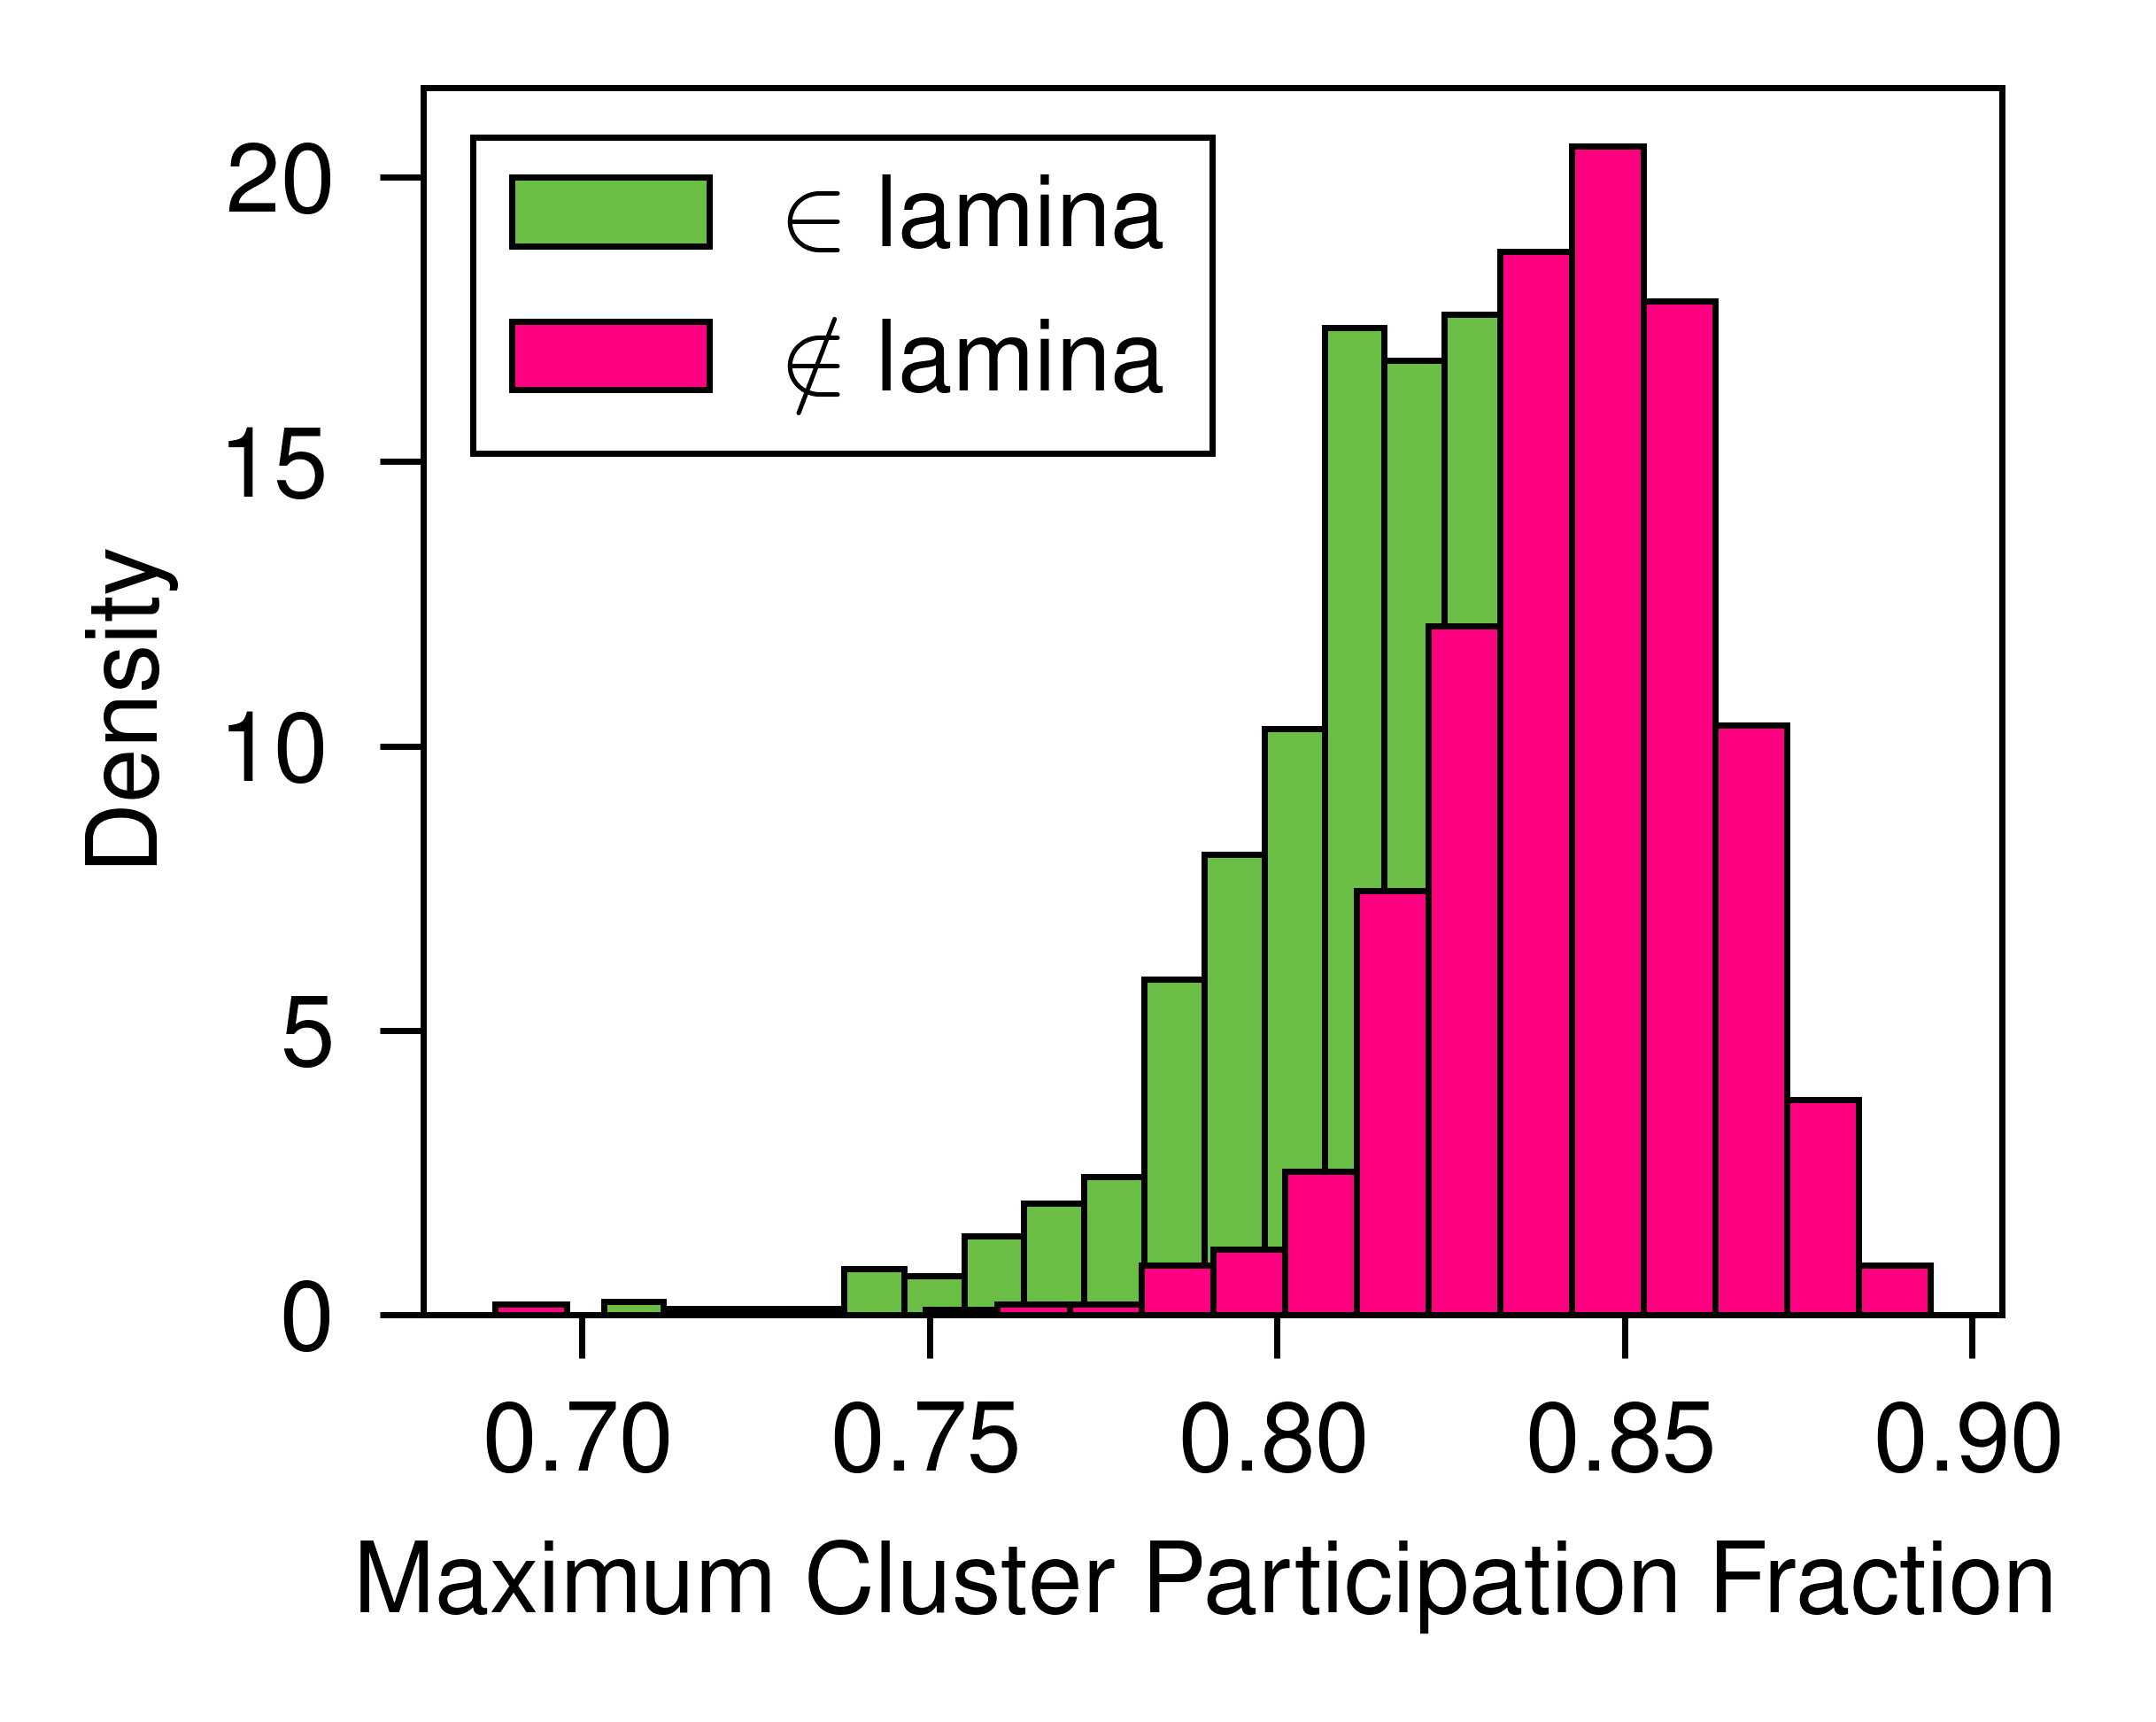

In [84]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(2.3, 1.8))

ax.hist(fmax, bins=20, density=True, label=title["complete"], color=color_palette["complete"])
ax.hist(fmax_no_lam, bins=20, density=True, label=title["nucleolus"], color=color_palette["nucleolus"])
ax.set_xlabel("Maximum Cluster Participation Fraction")
ax.set_ylabel("Density")
ax.legend()
plt.show()

In [ ]:


fmax_graph = []
rc = 1.78
N = positions.shape[1]

positions = traj.xyz(frames=range(0,10_000,10), beadSelection=[x for x in np.where(idx_B)[0]])

for frame in range(positions.shape[0]):
    xyz = positions[frame, :, :3]

    tree = cKDTree(xyz)

    pairs = tree.query_pairs(rc)

    pairs = [
        (i, j)
        for i, j in pairs
        if abs(i - j) > backbone_skip
    ]

    graph = coo_matrix(
        (
            np.ones(len(pairs)),
            (
                [p[0] for p in pairs],
                [p[1] for p in pairs]
            )
        ),
        shape=(N, N)
    )

    graph = graph + graph.T

    n_clusters, labels = connected_components(
        graph,
        directed=False
    )

    cluster_sizes = np.bincount(labels)

    fmax = cluster_sizes.max() / N
    Sw = np.sum(cluster_sizes**2) / N

    fmax_graph.append(cluster_sizes.max() / positions.shape[1])

In [ ]:


fmax_no_lam_graph = []
rc = 1.78
N = positions.shape[1]

# positions = traj.xyz(frames=range(0,10_000,10), beadSelection=[x for x in np.where(idx_B)[0]])

for frame in range(positions.shape[0]):
    xyz = positions[frame, :, :3]

    tree = cKDTree(xyz)

    pairs = tree.query_pairs(rc)

    pairs = [
        (i, j)
        for i, j in pairs
        if abs(i - j) > backbone_skip
    ]

    graph = coo_matrix(
        (
            np.ones(len(pairs)),
            (
                [p[0] for p in pairs],
                [p[1] for p in pairs]
            )
        ),
        shape=(N, N)
    )

    graph = graph + graph.T

    n_clusters, labels = connected_components(
        graph,
        directed=False
    )

    cluster_sizes = np.bincount(labels)

    fmax = cluster_sizes.max() / N
    Sw = np.sum(cluster_sizes**2) / N

    fmax_no_lam_graph.append(cluster_sizes.max() / positions.shape[1])

In [56]:
CONTACT_THRESHOLD = 0.50
MU = 3.22
RC = 1.78

rc = RC - 1 / MU * np.arctanh(2 * CONTACT_THRESHOLD - 1)

rc

1.78

In [90]:
fmax_no_lam

[0.8533988533988534,
 0.8816543816543817,
 0.8632268632268633,
 0.80999180999181,
 0.8472563472563472,
 0.8407043407043407,
 0.8214578214578214,
 0.8542178542178542,
 0.8333333333333334,
 0.7817362817362817,
 0.8243243243243243,
 0.8439803439803439,
 0.8636363636363636,
 0.8705978705978706,
 0.8370188370188371,
 0.8300573300573301,
 0.8701883701883701,
 0.8579033579033579,
 0.8624078624078624,
 0.8488943488943489,
 0.8603603603603603,
 0.8493038493038493,
 0.8677313677313677,
 0.8521703521703522,
 0.8665028665028665,
 0.864045864045864,
 0.8415233415233415,
 0.8382473382473382,
 0.8206388206388207,
 0.7944307944307945,
 0.8554463554463555,
 0.8263718263718264,
 0.8484848484848485,
 0.8251433251433251,
 0.8632268632268633,
 0.8321048321048321,
 0.8181818181818182,
 0.8394758394758395,
 0.8300573300573301,
 0.8677313677313677,
 0.8366093366093366,
 0.8230958230958231,
 0.8816543816543817,
 0.8771498771498771,
 0.8742833742833743,
 0.8566748566748567,
 0.8476658476658476,
 0.8550368550368

In [91]:
fmax_no_lam_graph

[0.8533988533988534,
 0.8816543816543817,
 0.8632268632268633,
 0.80999180999181,
 0.8472563472563472,
 0.8407043407043407,
 0.8214578214578214,
 0.8542178542178542,
 0.8333333333333334,
 0.7817362817362817,
 0.8243243243243243,
 0.8439803439803439,
 0.8636363636363636,
 0.8705978705978706,
 0.8370188370188371,
 0.8300573300573301,
 0.8701883701883701,
 0.8579033579033579,
 0.8624078624078624,
 0.8488943488943489,
 0.8603603603603603,
 0.8493038493038493,
 0.8677313677313677,
 0.8521703521703522,
 0.8665028665028665,
 0.864045864045864,
 0.8415233415233415,
 0.8382473382473382,
 0.8206388206388207,
 0.7944307944307945,
 0.8554463554463555,
 0.8263718263718264,
 0.8484848484848485,
 0.8251433251433251,
 0.8632268632268633,
 0.8321048321048321,
 0.8181818181818182,
 0.8394758394758395,
 0.8300573300573301,
 0.8677313677313677,
 0.8366093366093366,
 0.8230958230958231,
 0.8816543816543817,
 0.8771498771498771,
 0.8742833742833743,
 0.8566748566748567,
 0.8476658476658476,
 0.8550368550368

(array([ 0.31307692,  0.        ,  0.62615385,  0.62615385,  0.93923077,
         1.87846154,  3.75692308,  5.32230769, 10.33153846, 14.40153846,
        21.60230769, 29.11615385, 37.56923077, 49.15307692, 46.02230769,
        37.88230769, 32.87307692, 14.08846154,  5.63538462,  0.93923077]),
 array([0.91113841, 0.91433251, 0.91752662, 0.92072072, 0.92391482,
        0.92710893, 0.93030303, 0.93349713, 0.93669124, 0.93988534,
        0.94307944, 0.94627355, 0.94946765, 0.95266175, 0.95585586,
        0.95904996, 0.96224406, 0.96543817, 0.96863227, 0.97182637,
        0.97502048]),
 [<matplotlib.patches.Polygon at 0x7fecd55ddea0>])

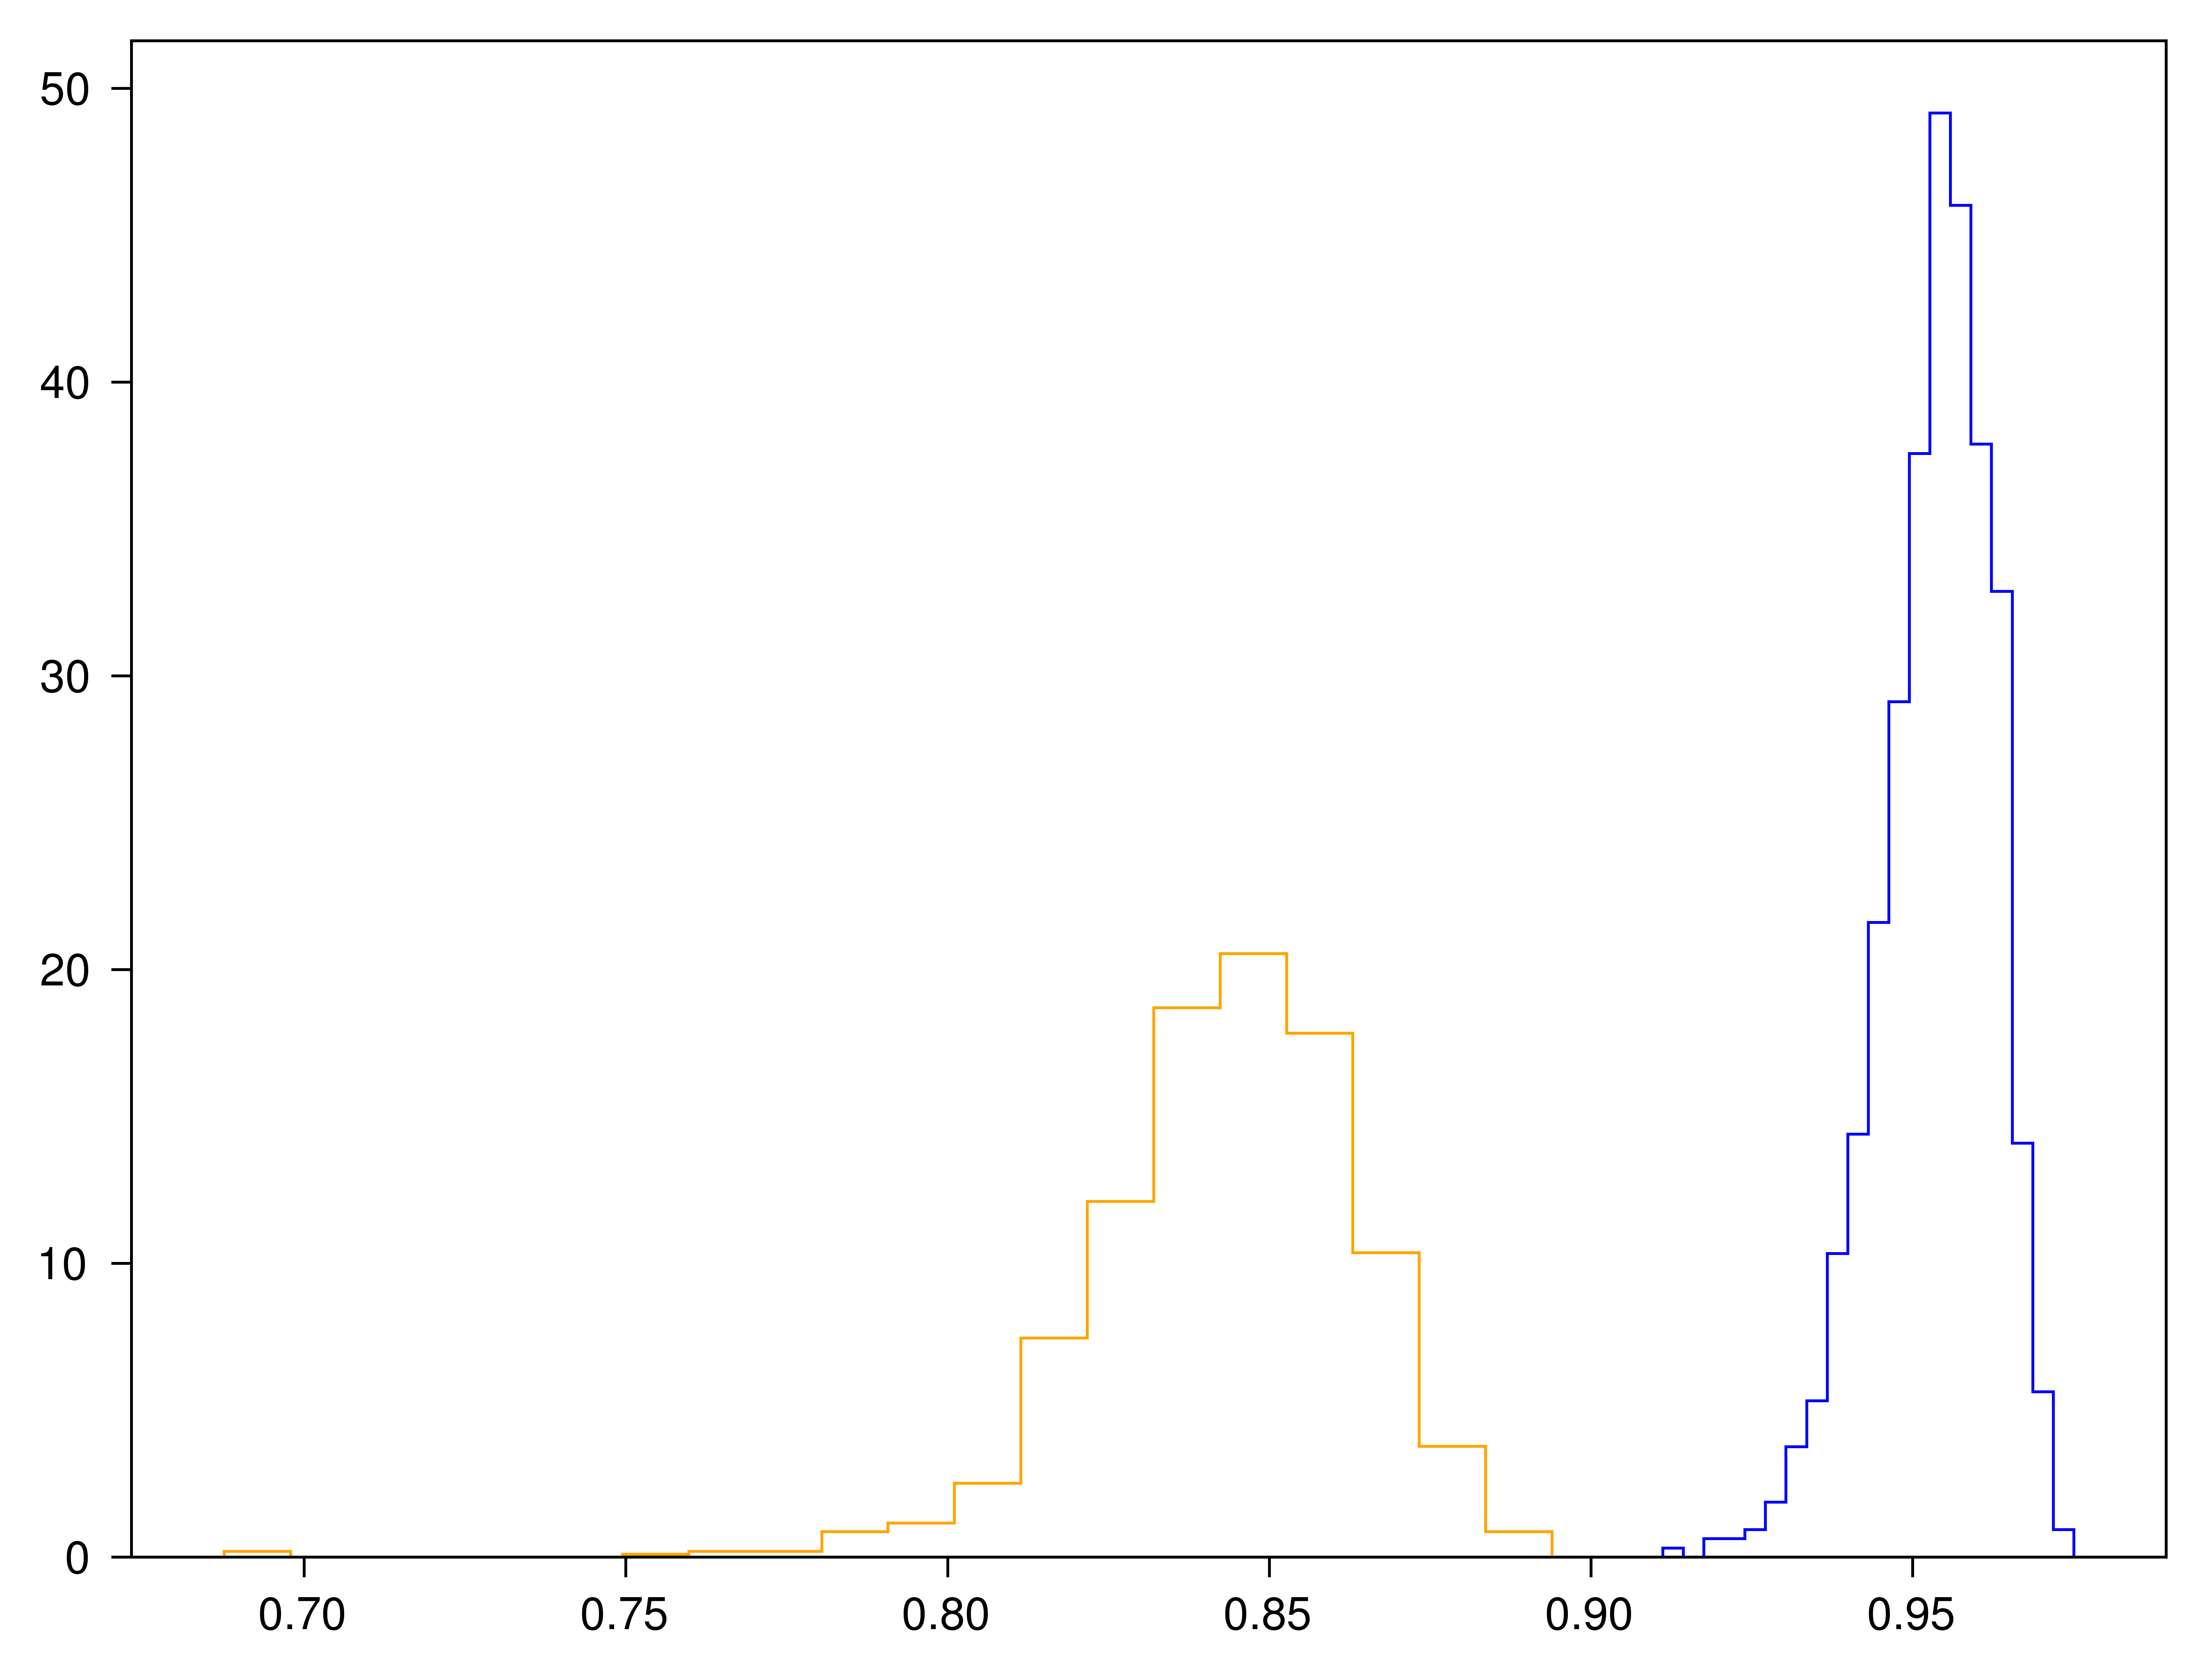

In [98]:
plt.hist(fmax_no_lam, bins=20, density=True, label=title["nucleolus"], color="orange", histtype="step")
plt.hist(fmax_no_lam_graph, bins=20, density=True, label=title["nucleolus"], color="blue", histtype="step")

(array([ 0.31307692,  0.        ,  0.62615385,  0.62615385,  0.93923077,
         1.87846154,  3.75692308,  5.32230769, 10.33153846, 14.40153846,
        21.60230769, 29.11615385, 37.56923077, 49.15307692, 46.02230769,
        37.88230769, 32.87307692, 14.08846154,  5.63538462,  0.93923077]),
 array([0.91113841, 0.91433251, 0.91752662, 0.92072072, 0.92391482,
        0.92710893, 0.93030303, 0.93349713, 0.93669124, 0.93988534,
        0.94307944, 0.94627355, 0.94946765, 0.95266175, 0.95585586,
        0.95904996, 0.96224406, 0.96543817, 0.96863227, 0.97182637,
        0.97502048]),
 <BarContainer object of 20 artists>)

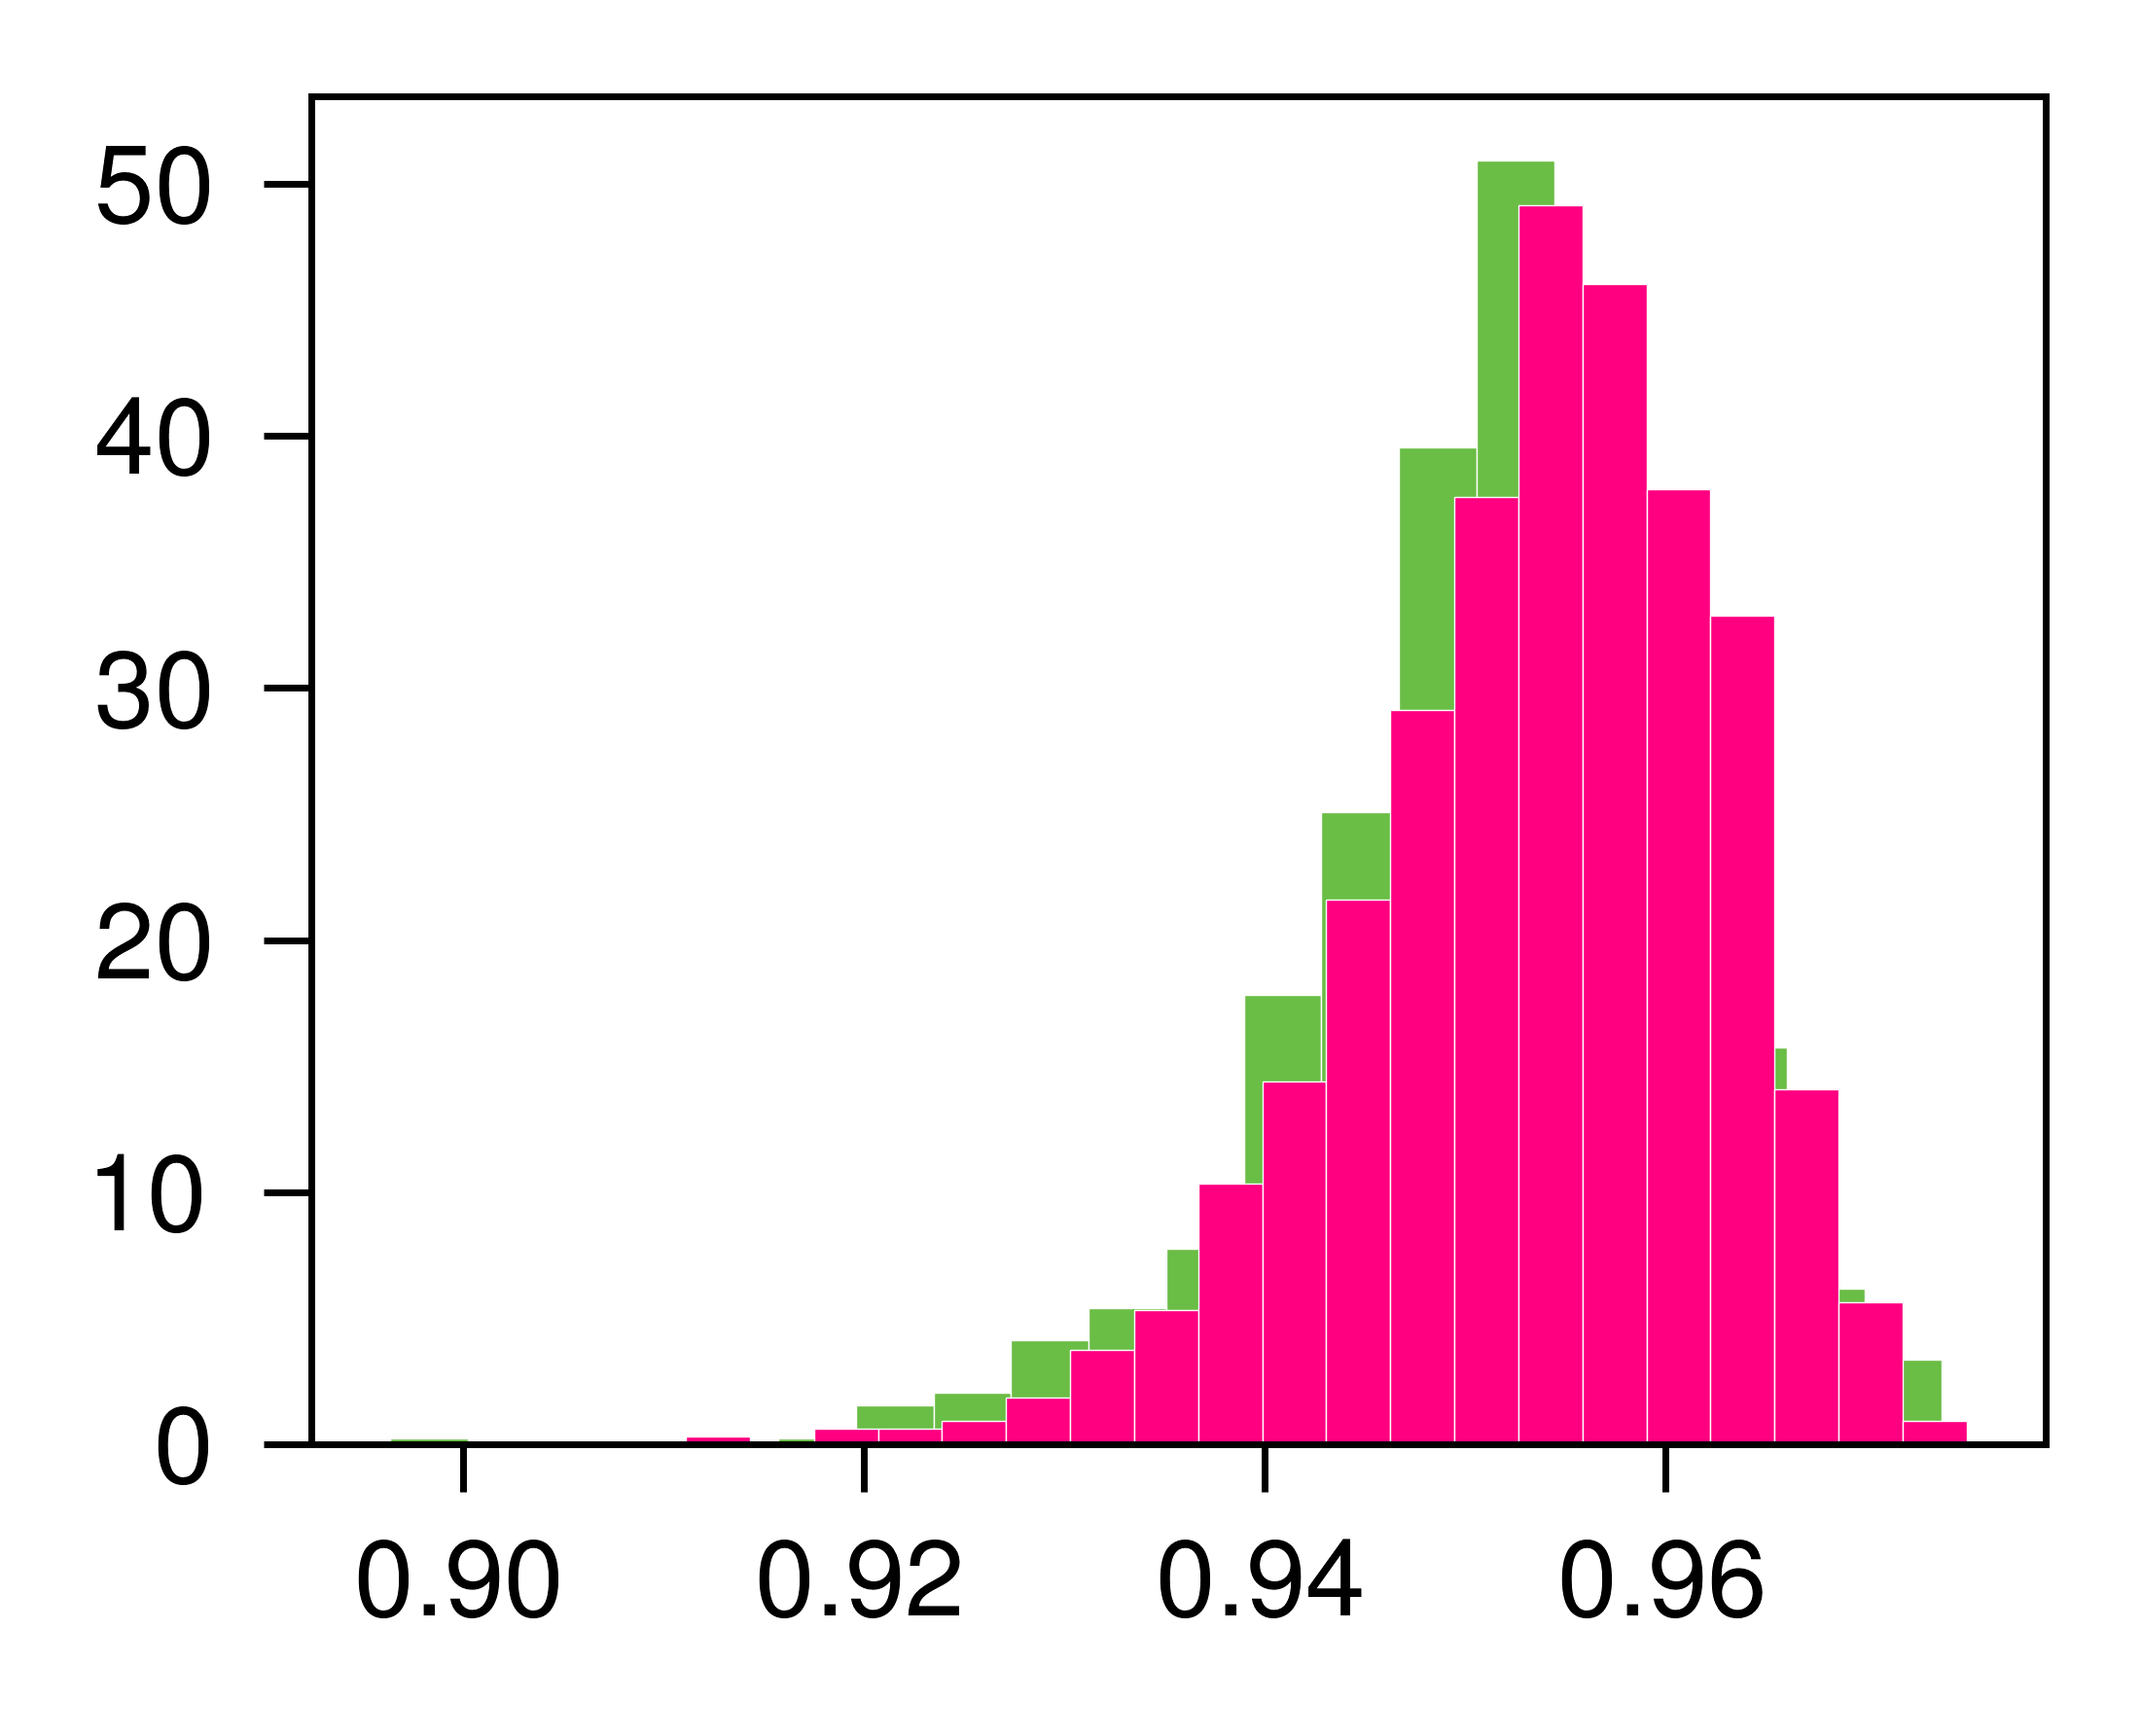

In [109]:
fig, ax = plt.subplots(figsize=(2.3, 1.8))

ax.hist(
    fmax_graph,
    bins=20,
    density=True,
    label=title["complete"],
    color=color_palette["complete"],
    edgecolor="white",
    linewidth=0.1,
    # histtype="step"
)
ax.hist(
    fmax_no_lam_graph,
    bins=20,
    density=True,
    label=title["nucleolus"],
    color=color_palette["nucleolus"],
    edgecolor="white",
    linewidth=0.1,
    # histtype="step",
    # linestyle="--"
)

# nuclear bodies as beads

## chr1

### $f(r) \ge 0.90$

In [97]:
conditions = ["complete", "nucleolus"]

NUM_REPLICAS = 96
NUM_BEADS = 4980
NUCLEUS_RADIUS = 32.5
NUCLEOLI_RADIUS = (NUCLEUS_RADIUS) / 5 ** (1 / 3)
CHROMATIN_DENSITY = 0.30

OUTPUT_FOLDER = "/scratch/mm146/Polarization/4_IMR-90_hg38_chr1/7_analysis/cluster-size/data-0.90"

In [98]:
color_palette = yaml.safe_load(open("../color-palette.yaml", "r"))

In [99]:
title = {
    "complete": r"$\in~$lamina",
    "nucleolus": r"$\notin~$lamina",
}

#### Aggregate contact data


In [69]:
cluster_size = {}

for condition in conditions:
    cluster_size[condition] = {}
    for replica in range(1, NUM_REPLICAS + 1):
        print(f"Processing {condition} replica {replica}")
        with h5py.File(
            f"{OUTPUT_FOLDER}/{condition}/cluster-size-replica{replica}.h5",
            "r",
        ) as f:
            for key in f.keys():
                if key not in cluster_size[condition]:
                    cluster_size[condition][key] = []
                cluster_size[condition][key].append(f[key][()] * 4980 / 2442)

    for key in cluster_size[condition]:
        cluster_size[condition][key] = np.concatenate(cluster_size[condition][key], axis=0)

Processing complete replica 1
Processing complete replica 2
Processing complete replica 3
Processing complete replica 4
Processing complete replica 5
Processing complete replica 6
Processing complete replica 7
Processing complete replica 8
Processing complete replica 9
Processing complete replica 10
Processing complete replica 11
Processing complete replica 12
Processing complete replica 13
Processing complete replica 14
Processing complete replica 15
Processing complete replica 16
Processing complete replica 17
Processing complete replica 18
Processing complete replica 19
Processing complete replica 20
Processing complete replica 21
Processing complete replica 22
Processing complete replica 23
Processing complete replica 24
Processing complete replica 25
Processing complete replica 26
Processing complete replica 27
Processing complete replica 28
Processing complete replica 29
Processing complete replica 30
Processing complete replica 31
Processing complete replica 32
Processing comple

In [70]:
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "cluster-size-data-aggregated.h5"), "w"
) as f:
    for condition in cluster_size.keys():
        grp = f.create_group(condition)
        for key in cluster_size[condition].keys():
            grp.create_dataset(key, data=cluster_size[condition][key])

#### Plotting contact analyses

In [100]:
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "cluster-size-data-aggregated.h5"), "r"
) as f:
    cluster_size = {
        condition: f[condition]["cluster_size"][()]
        for condition in f.keys()
    }

In [101]:
cluster_size["complete"].shape

(960000,)

(70.0, 90.0)

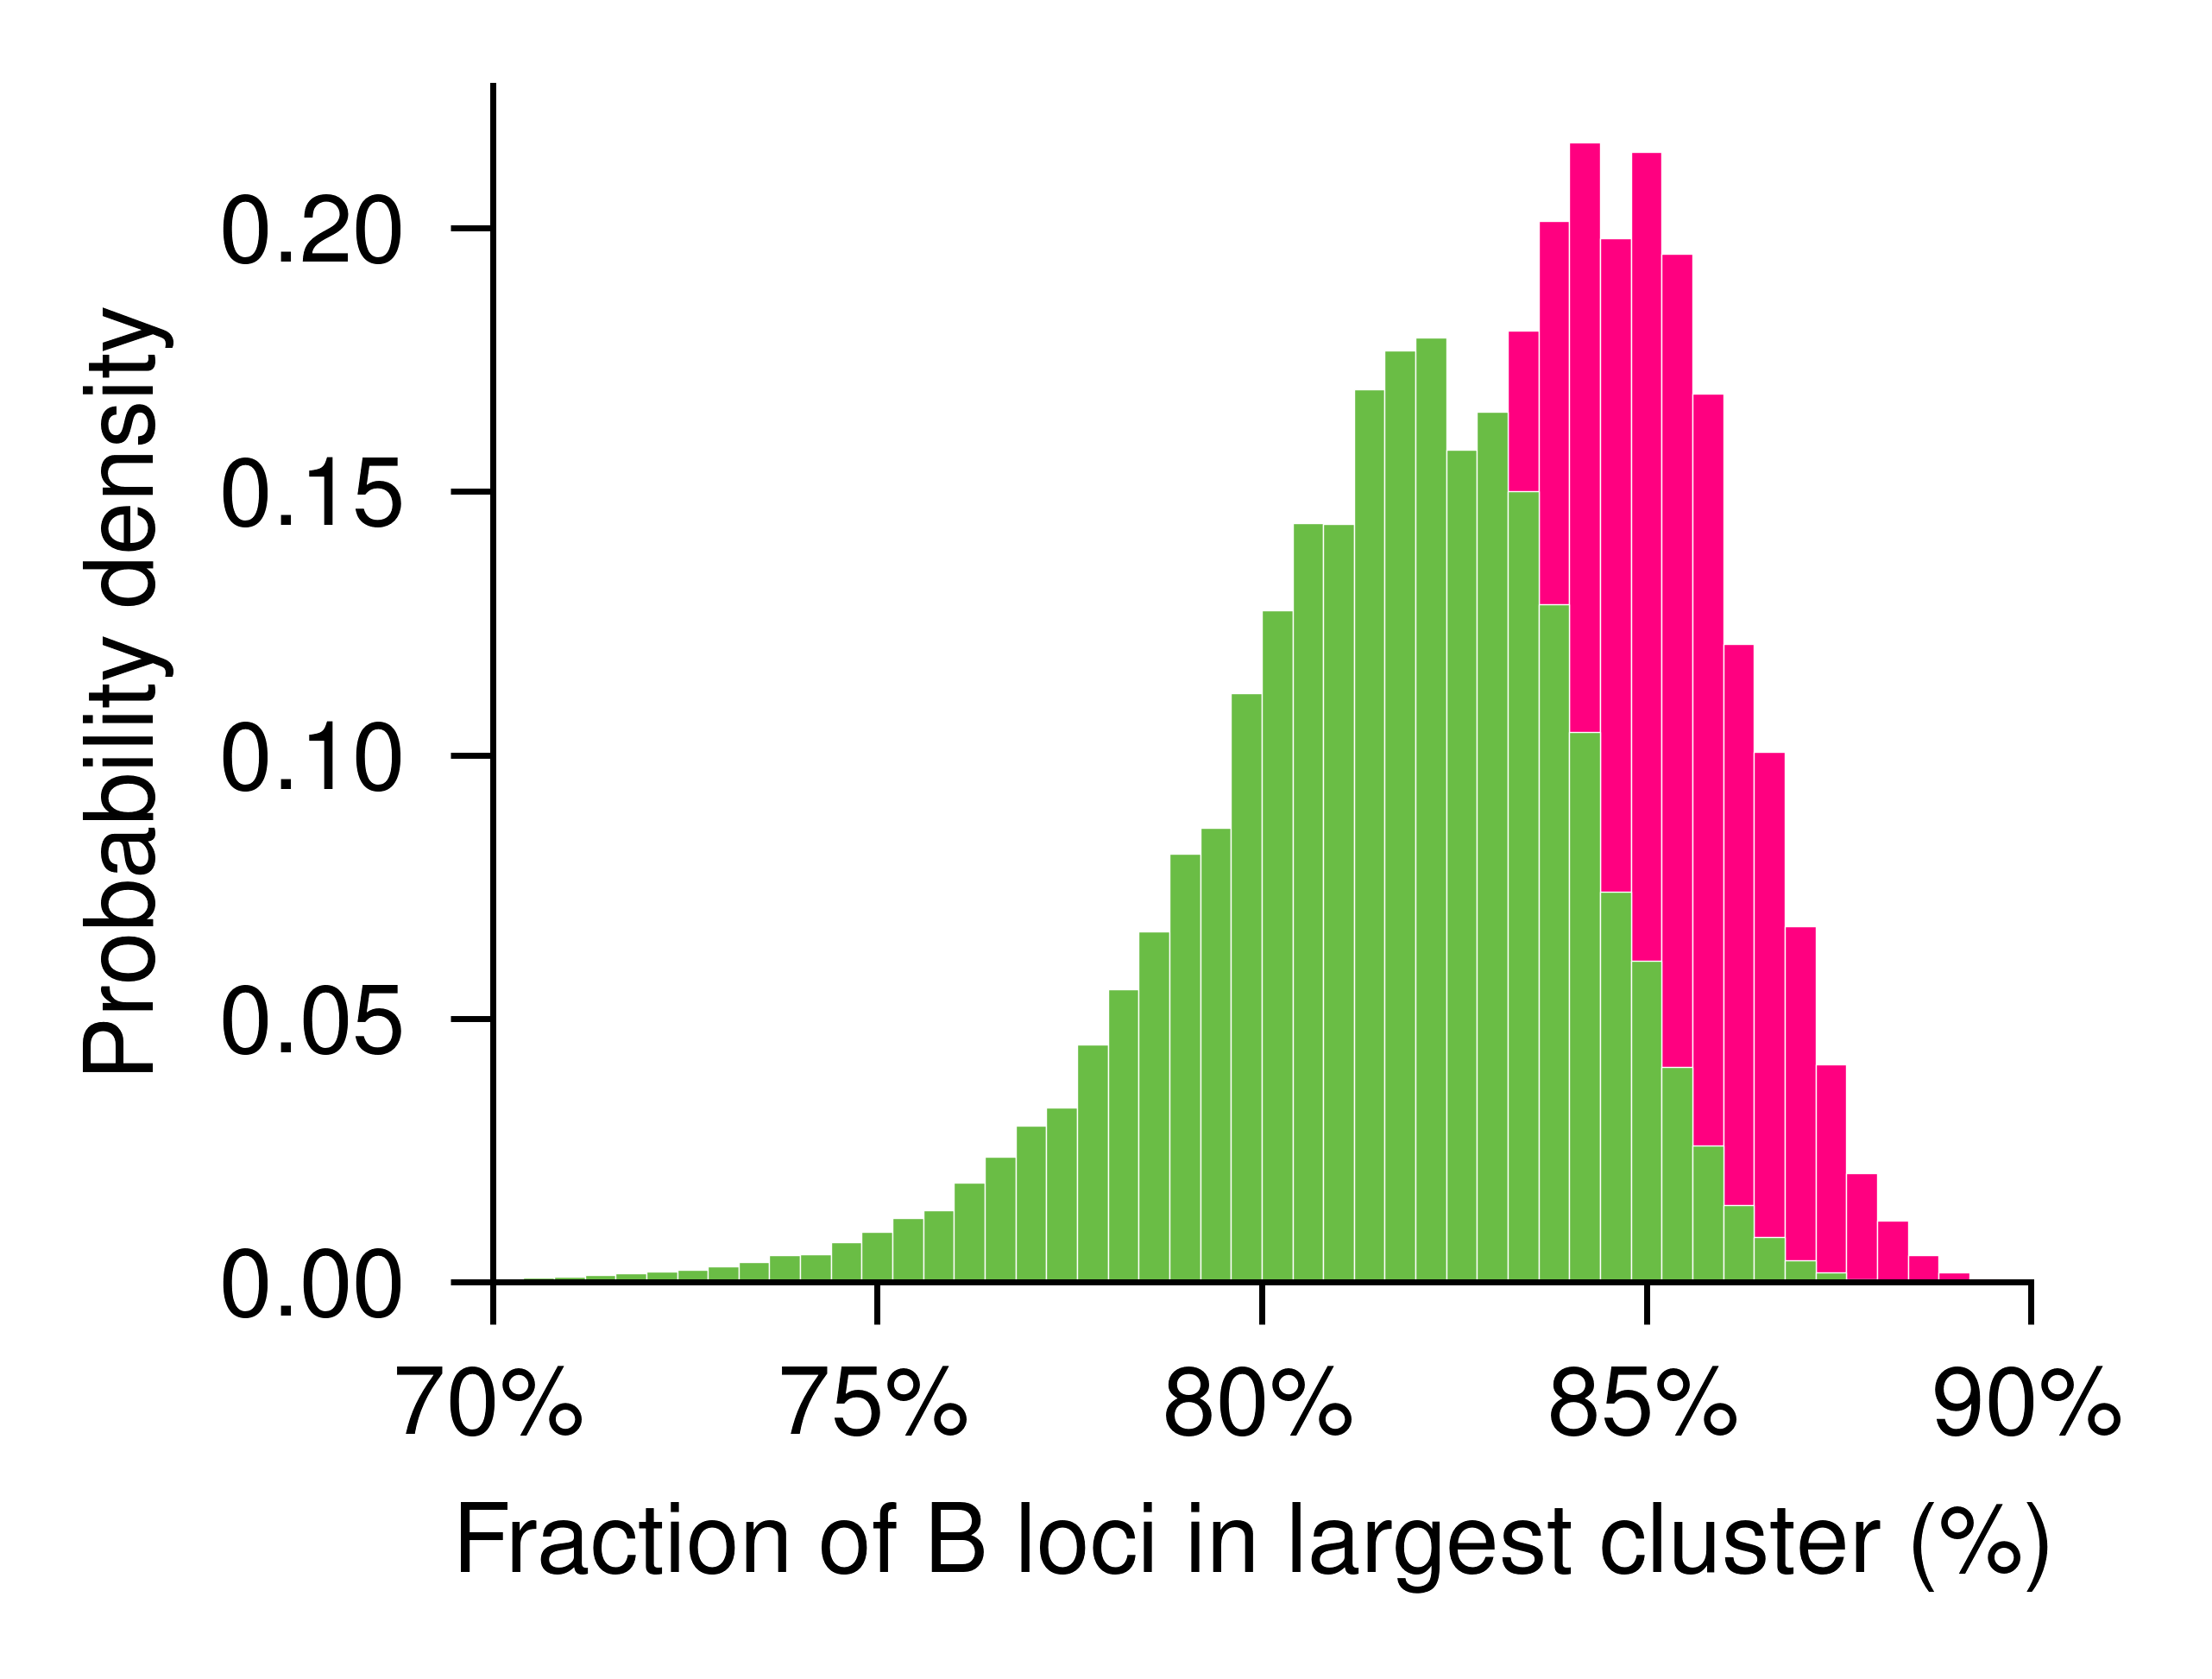

In [102]:
fig, ax = plt.subplots(figsize=(2.3, 1.8))

bins = np.linspace(70, 90, 51)

for i, condition in enumerate(conditions):
    cluster = cluster_size[condition]
    ax.hist(
        cluster * 100,
        bins=bins,
        density=True,
        label=title[condition],
        color=color_palette[condition],
        edgecolor="white",
        linewidth=0.1,
        zorder=2-i
    )

ax.set_xlabel("Fraction of B loci in largest cluster (\%)")
ax.set_ylabel("Probability density")

ax.spines[["top", "right"]].set_visible(False)

xticks = ax.get_xticks()
ax.set_xticks(xticks)
ax.set_xticklabels([f"{x:.0f}\%" for x in xticks])
ax.set_xlim(bins[0], bins[-1])

### $f(r) \ge 0.50$

In [2]:
conditions = ["complete", "nucleolus"]

NUM_REPLICAS = 96
NUM_BEADS = 4980
NUCLEUS_RADIUS = 32.5
NUCLEOLI_RADIUS = (NUCLEUS_RADIUS) / 5 ** (1 / 3)
CHROMATIN_DENSITY = 0.30

OUTPUT_FOLDER = "/scratch/mm146/Polarization/4_IMR-90_hg38_chr1/7_analysis/cluster-size/data-0.50"

In [3]:
color_palette = yaml.safe_load(open("../color-palette.yaml", "r"))

In [4]:
title = {
    "complete": r"$\in~$lamina",
    "nucleolus": r"$\notin~$lamina",
}

#### Aggregate contact data


In [78]:
cluster_size = {}

for condition in conditions:
    cluster_size[condition] = {}
    for replica in range(1, NUM_REPLICAS + 1):
        print(f"Processing {condition} replica {replica}")
        with h5py.File(
            f"{OUTPUT_FOLDER}/{condition}/cluster-size-replica{replica}.h5",
            "r",
        ) as f:
            for key in f.keys():
                if key not in cluster_size[condition]:
                    cluster_size[condition][key] = []
                cluster_size[condition][key].append(f[key][()] * 4980 / 2442)

    for key in cluster_size[condition]:
        cluster_size[condition][key] = np.concatenate(cluster_size[condition][key], axis=0)

Processing complete replica 1
Processing complete replica 2
Processing complete replica 3
Processing complete replica 4
Processing complete replica 5
Processing complete replica 6
Processing complete replica 7
Processing complete replica 8
Processing complete replica 9
Processing complete replica 10
Processing complete replica 11
Processing complete replica 12
Processing complete replica 13
Processing complete replica 14
Processing complete replica 15
Processing complete replica 16
Processing complete replica 17
Processing complete replica 18
Processing complete replica 19
Processing complete replica 20
Processing complete replica 21
Processing complete replica 22
Processing complete replica 23
Processing complete replica 24
Processing complete replica 25
Processing complete replica 26
Processing complete replica 27
Processing complete replica 28
Processing complete replica 29
Processing complete replica 30
Processing complete replica 31
Processing complete replica 32
Processing comple

In [79]:
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "cluster-size-data-aggregated.h5"), "w"
) as f:
    for condition in cluster_size.keys():
        grp = f.create_group(condition)
        for key in cluster_size[condition].keys():
            grp.create_dataset(key, data=cluster_size[condition][key])

#### Plotting contact analyses

In [5]:
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "cluster-size-data-aggregated.h5"), "r"
) as f:
    cluster_size = {
        condition: f[condition]["cluster_size"][()]
        for condition in f.keys()
    }

In [11]:
cluster_size["complete"].shape

(960000,)

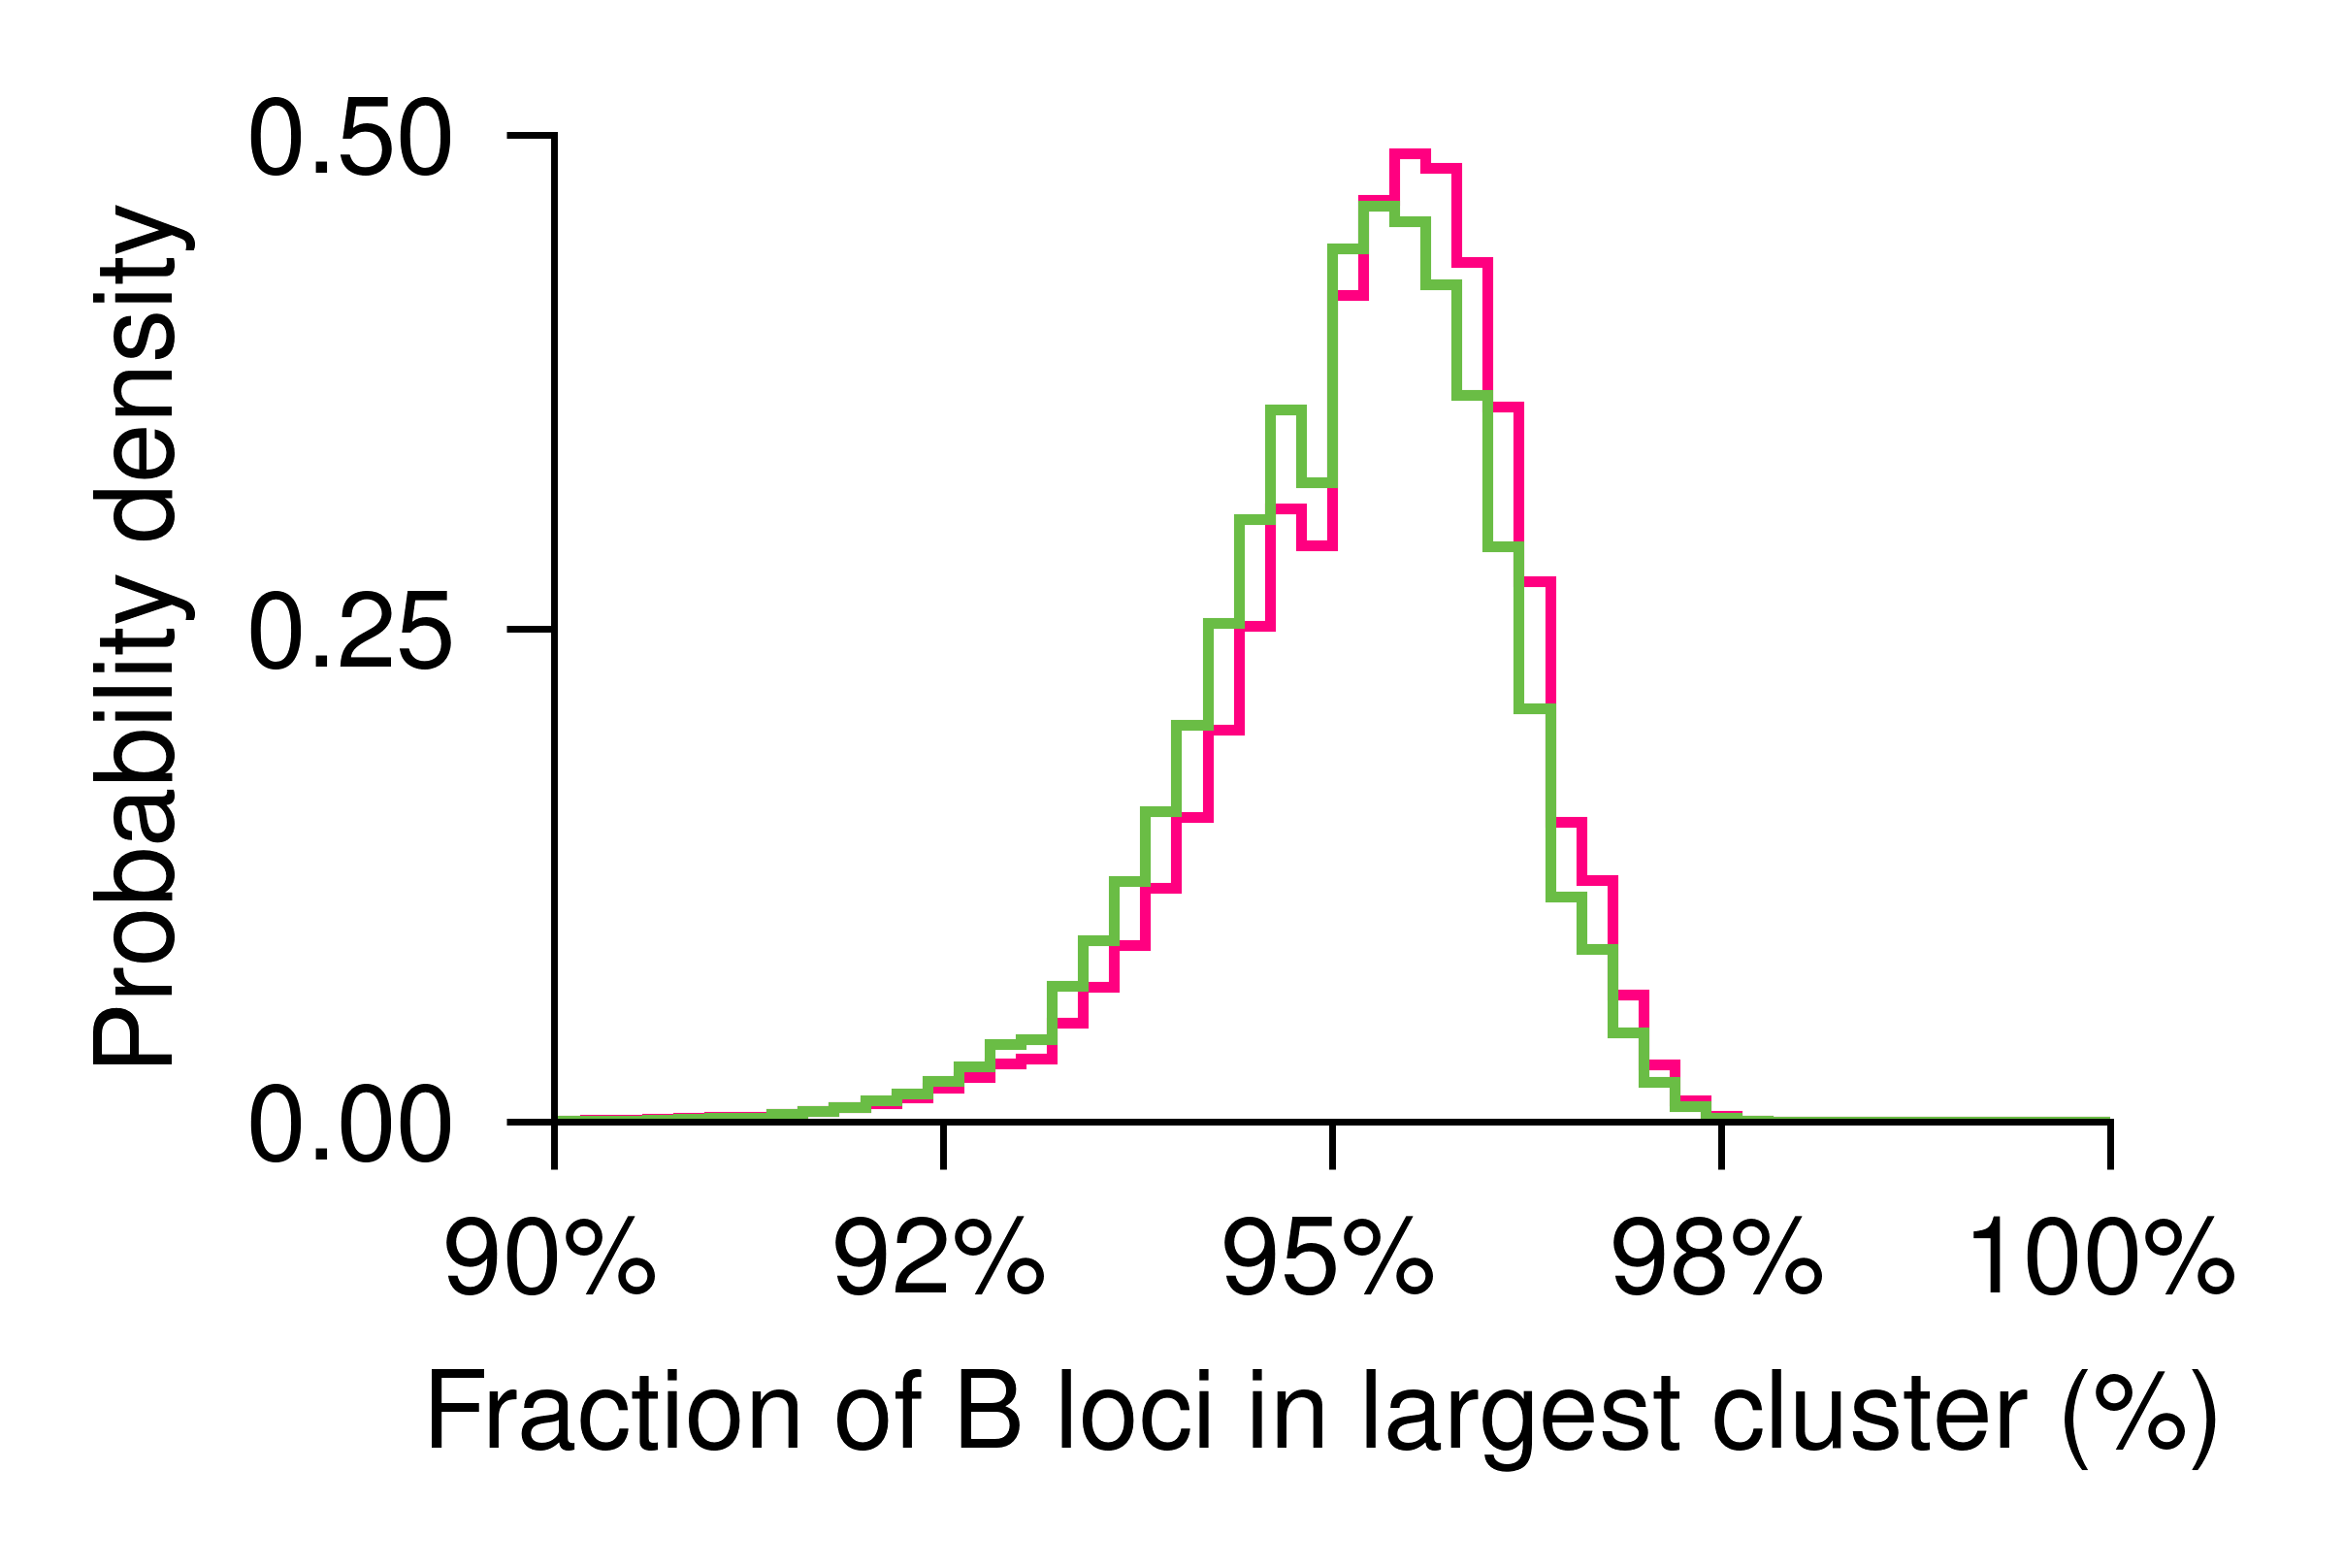

In [13]:
fig, ax = plt.subplots(figsize=(2.3, 1.5), layout="constrained")

bins = np.linspace(90, 100, 51)

for i, condition in enumerate(conditions):
    cluster = cluster_size[condition]
    ax.hist(
        cluster * 100,
        bins=bins,
        density=True,
        label=title[condition],
        color=color_palette[condition],
        # edgecolor="white",
        linewidth=0.8,
        zorder=2-i,
        histtype="step",
    )

ax.set_xlabel("Fraction of B loci in largest cluster (\%)")
ax.set_ylabel("Probability density")

ax.spines[["top", "right"]].set_visible(False)

xticks = ax.get_xticks()
ax.set_xticks(xticks)
ax.set_xticklabels([f"{x:.0f}\%" for x in xticks])
ax.set_xlim(bins[0], bins[-1])

ax.set_yticks([0, 0.25, 0.5])
ax.set_ylim(0, 0.5)

fig.savefig("figures/fig-cluster-size-0.50.pdf")

(90.0, 100.0)

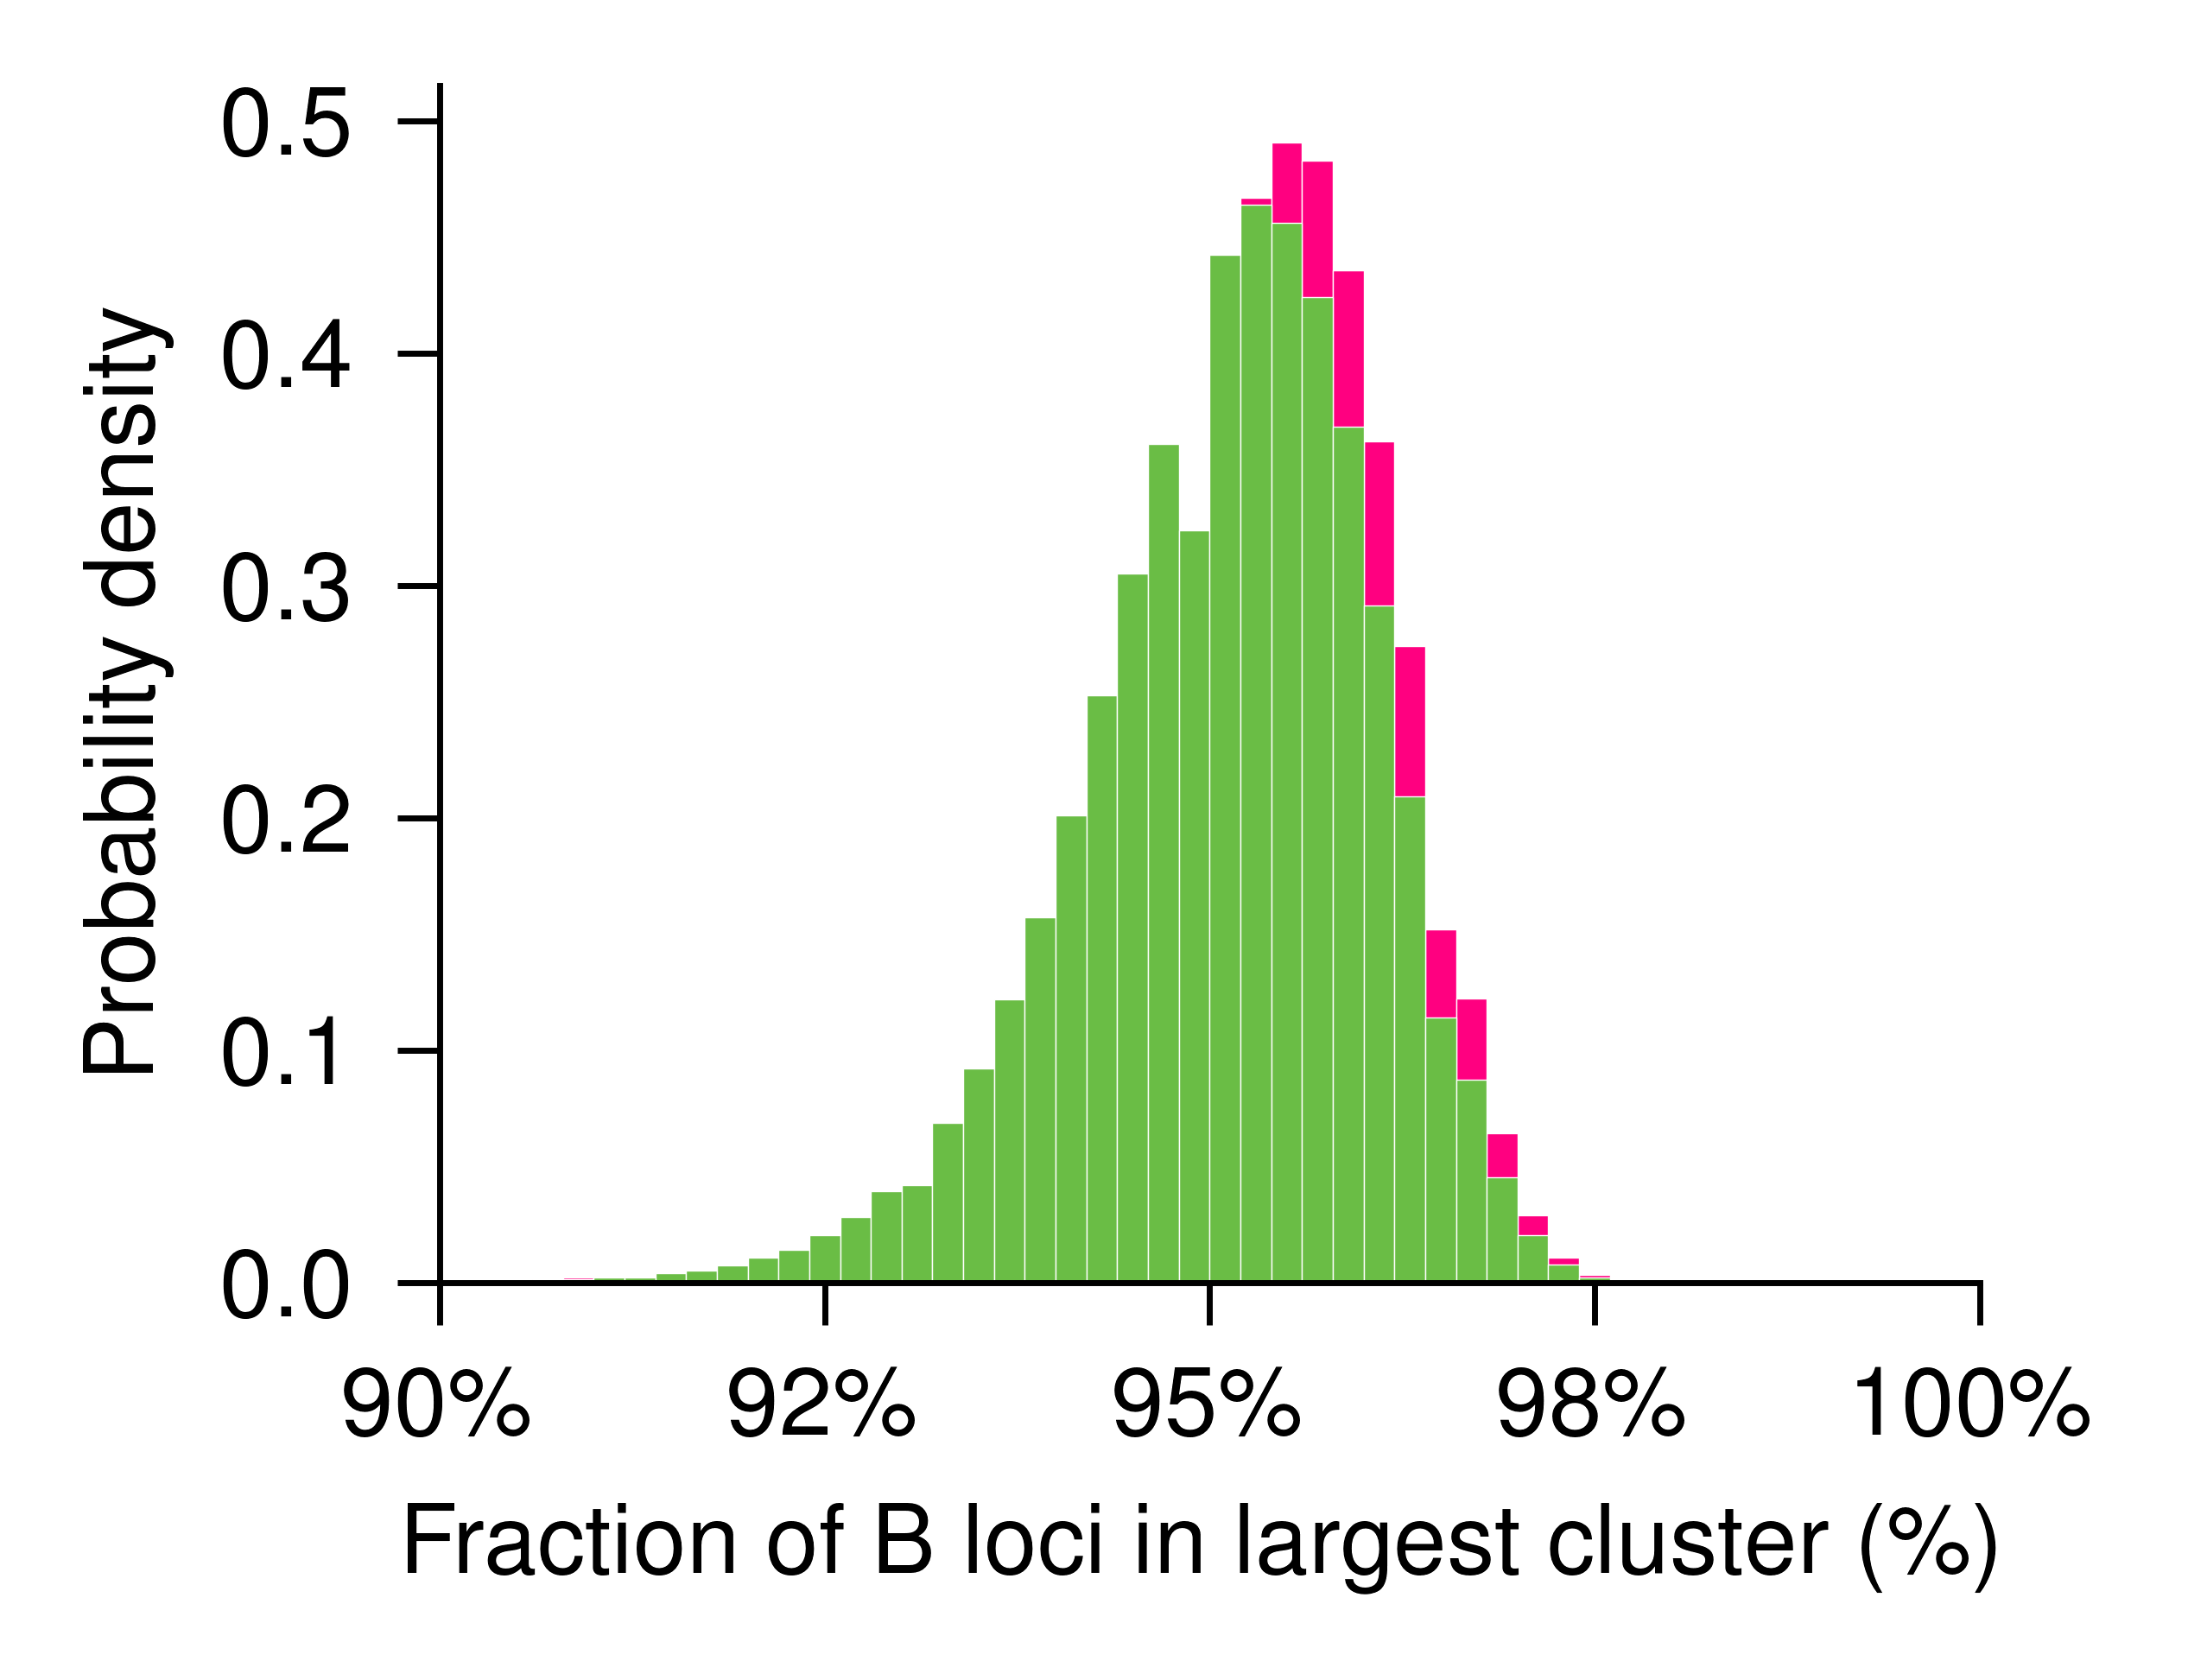

In [109]:
fig, ax = plt.subplots(figsize=(2.3, 1.8))

bins = np.linspace(90, 100, 51)

for i, condition in enumerate(conditions):
    cluster = cluster_size[condition]
    ax.hist(
        cluster * 100,
        bins=bins,
        density=True,
        label=title[condition],
        color=color_palette[condition],
        edgecolor="white",
        linewidth=0.1,
        zorder=2-i,
        # histtype="step",
    )

ax.set_xlabel("Fraction of B loci in largest cluster (\%)")
ax.set_ylabel("Probability density")

ax.spines[["top", "right"]].set_visible(False)

xticks = ax.get_xticks()
ax.set_xticks(xticks)
ax.set_xticklabels([f"{x:.0f}\%" for x in xticks])
ax.set_xlim(bins[0], bins[-1])